In [1]:
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, precision_recall_curve, 
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

X_train = joblib.load('../models/X_train.pkl')
X_test = joblib.load('../models/X_test.pkl')
y_train = joblib.load('../models/y_train.pkl')
y_test = joblib.load('../models/y_test.pkl')

In [2]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [3]:
y_pred_baseline = baseline_model.predict(X_test)

print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



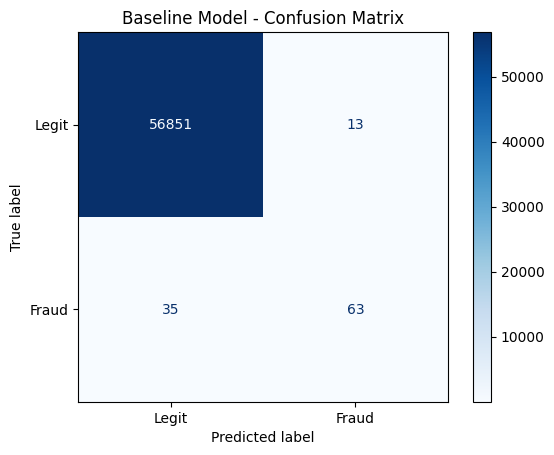

In [4]:
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Baseline Model - Confusion Matrix')
plt.show()

In [5]:
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_proba_baseline)

0.9558983554029378

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [7]:
smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [8]:
joblib.dump(baseline_model, '../models/baseline_logreg.pkl')
joblib.dump(smote_model, '../models/smote_logreg.pkl')
joblib.dump(X_train_smote, '../models/X_train_smote.pkl')
joblib.dump(y_train_smote, '../models/y_train_smote.pkl')

['../models/y_train_smote.pkl']